In [1]:
import matplotlib.pyplot as plt
import numpy as np
from helpers import load_trail

from utils.functions import get_hv_max

In [2]:
def wrap_label(label, max_width=4000): 
    if len(label) <= max_width:
        return label
    
    lines = []
    words = label.split(' ')
    current_line = ""
    
    for word in words:
        test_line = current_line + " " + word if current_line else word
        if len(test_line) <= max_width:
            current_line = test_line
        else:
            if len(current_line) > 0:
                lines.append(current_line.strip())
            if len(word) > max_width:
                while len(word) > max_width:
                    lines.append(word[:max_width])
                    word = word[max_width:]
                if word: 
                    lines.append(word)
                current_line = ""
            else:
                current_line = word 
    
    if current_line:
        lines.append(current_line)
    
    return '\n'.join(lines)

Text(0.5, 0, 'time (s)')

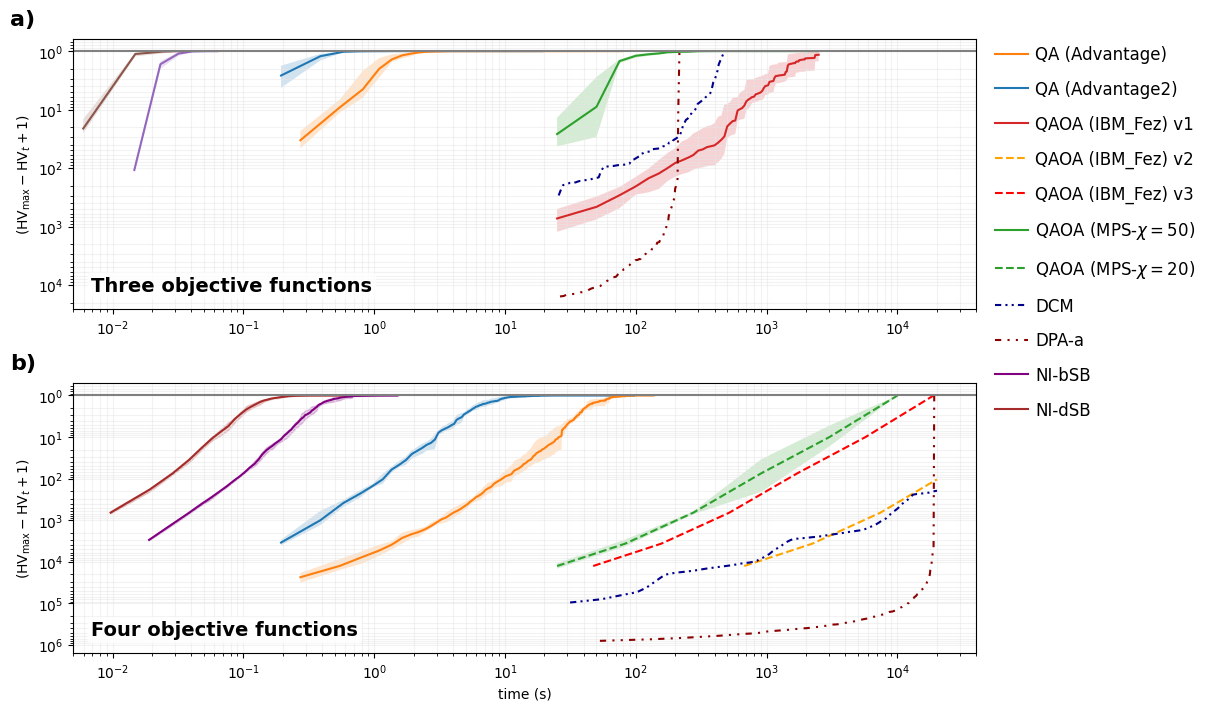

In [3]:
# =============================================================================
# Figure & Grid Setup
# =============================================================================
fig = plt.figure(figsize=(12, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[12, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)

solvernames = ['Advantage2_system1.7', 'Advantage_system4.1']

# =============================================================================
# Main Plotting Loop (3 vs 4 Objectives)
# =============================================================================
for idx, num_objectives in enumerate([3, 4]):
    ax = ax1 if idx == 0 else ax2
    hv_max = get_hv_max(num_objectives)
    
    # -------------------------------------------------------------------------
    # 1. QA Data
    # -------------------------------------------------------------------------
    labels_qa = ['QA (Advantage2)', 'QA (Advantage)']
    for isolver, solvername in enumerate(solvernames):
        qtime, hv = [], []
        for rep in range(5):
            data = np.load(f'data_QA/results/{solvername}/Nobj{num_objectives}_rep{rep}.npz')
            qtime.append(data['qpu_access_time'])
            hv.append(data['hypervolume'])
            
        completed_iter = min(len(_) for _ in qtime)
        qtime = np.array([arr[:completed_iter] for arr in qtime])
        hv = np.array([arr[:completed_iter] for arr in hv])
        
        t_cum = np.cumsum(np.mean(qtime, axis=0))
        y_mean = 1 + hv_max - np.mean(hv, axis=0)
        y_low  = 1 + hv_max - np.max(hv, axis=0)
        y_high = 1 + hv_max - np.min(hv, axis=0)
        
        ax.fill_between(t_cum, y_low, y_high, alpha=0.2)
        ax.plot(t_cum, y_mean, label=labels_qa[isolver])

    # -------------------------------------------------------------------------
    # 2. MPS Data
    # -------------------------------------------------------------------------
    if num_objectives == 3:
        data = dict(np.load('data_QA/s43588-025-00873-y_plotdata/plotdata_3obj_mps.npz'))
        ax.fill_between(data['x'], np.min(data['y'], axis=0), np.max(data['y'], axis=0), alpha=0.2)
        ax.plot(data['x'], np.mean(data['y'], axis=0), label=r'QAOA (MPS-$\chi=50$)')
    else:
        data = dict(np.load('data_QA/s43588-025-00873-y_plotdata/plotdata_4obj_mps.npz'))
        ax.fill_between(data['x'], 1 + hv_max - np.max(data['y'], axis=0), 1 + hv_max - np.min(data['y'], axis=0), alpha=0.2)
        ax.plot(data['x'], 1 + hv_max - np.mean(data['y'], axis=0), linestyle='--', label=r'QAOA (MPS-$\chi=20$)')

    # -------------------------------------------------------------------------
    # 3. IBM Fez Data
    # -------------------------------------------------------------------------
    if num_objectives == 3:
        data = dict(np.load('data_QA/s43588-025-00873-y_plotdata/plotdata_3obj_ibm.npz'))
        ax.fill_between(data['x'], np.min(data['y'], axis=0), np.max(data['y'], axis=0), alpha=0.2)
        ax.plot(data['x'], np.mean(data['y'], axis=0), label='QAOA (IBM_Fez) v1')
    else:
        data = dict(np.load('data_QA/s43588-025-00873-y_plotdata/plotdata_4obj_hw_3percent.npz'))
        ax.plot(data['x'], data['y'], linestyle='--', color=str(data['color']), label='QAOA (IBM_Fez) v2')
        
        data = dict(np.load('data_QA/s43588-025-00873-y_plotdata/plotdata_4obj_hw_53percent.npz'))
        ax.plot(data['x'], data['y'], linestyle='--', color='red', label='QAOA (IBM_Fez) v3')

    # -------------------------------------------------------------------------
    # 4. DCM & DPA-a
    # -------------------------------------------------------------------------
    dcm_fname = f'plotdata_{num_objectives}obj_dcm.npz'
    dpa_fname = f'plotdata_{num_objectives}obj_dpa-a.npz'
    
    for fname, lbl, ls in [
        (dcm_fname, 'DCM',   (0, (3, 2, 1, 2, 1, 2))),
        (dpa_fname, 'DPA-a', (0, (3, 3, 1, 3, 1, 3)))
    ]:
        data = dict(np.load(f'data_QA/s43588-025-00873-y_plotdata/{fname}'))
        if num_objectives == 4:
            ax.plot(data['x'], data['y'], linestyle=ls, color=str(data['color']), label=lbl)
        else:
            ax.plot(data['x'], data['y'], linestyle=ls, color=str(data['color']))

    # -------------------------------------------------------------------------
    # 5. NI-bSB & NI-dSB
    # -------------------------------------------------------------------------
    t_b, y_b, y_b_min, y_b_max = load_trail(str(num_objectives), 'b', category='sample', path='./raw_data/')
    t_d, y_d, y_d_min, y_d_max = load_trail(str(num_objectives), 'd', category='sample', path='./raw_data/')
    
    if num_objectives == 3:
        ax.fill_between(t_b, y_b_min, y_b_max, alpha=0.2)
        ax.plot(t_b, y_b)
        ax.fill_between(t_d, y_d_min, y_d_max, alpha=0.2)
        ax.plot(t_d, y_d)
    else:
        ax.fill_between(t_b, y_b_min, y_b_max, alpha=0.2, color='purple')
        ax.plot(t_b, y_b, label=r'NI-bSB', color='purple')
        ax.fill_between(t_d, y_d_min, y_d_max, alpha=0.2, color='brown')
        ax.plot(t_d, y_d, label=r'NI-dSB', color='brown')

    # -------------------------------------------------------------------------
    # 6. Reference Line & Axis Styling
    # -------------------------------------------------------------------------
    x_start = 0.003 if num_objectives == 3 else 0.005
    x_end = 5000 if num_objectives == 3 else 40000
    
    ax.plot([x_start, 1e5], [1, 1], '-', color=[0.5, 0.5, 0.5])
    ax.set_xlim(x_start, x_end)
    ax.loglog()
    ax.grid(which='both', axis='both', color=[0.9, 0.9, 0.9], alpha=0.5)
    ax.invert_yaxis()
    
    # Title box (bottom-left)
    title_text = "Three objective functions" if idx == 0 else "Four objective functions"
    ax.text(0.02, 0.05, title_text, transform=ax.transAxes,
            ha='left', va='bottom', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# =============================================================================
# Panel Labels & Unified Legend
# =============================================================================
ax1.text(-0.07, 1.05, 'a)', transform=ax1.transAxes, fontweight='bold', fontsize=16)
ax2.text(-0.07, 1.05, 'b)', transform=ax2.transAxes, fontweight='bold', fontsize=16)

# Collect unique handles/labels from both subplots
handles, labels = [], []
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels:
            handles.append(hi)
            labels.append(li)

# Create dedicated axis for legend
ax_legend = fig.add_subplot(gs[:, 1])
ax_legend.axis('off')

# Apply wrapping & enforce specific legend order
wrapped_labels = [wrap_label(l) for l in labels]
desired_order = [
    'QA (Advantage)', 'QA (Advantage2)', 'QAOA (IBM_Fez) v1',
    'QAOA (IBM_Fez) v2', 'QAOA (IBM_Fez) v3', r'QAOA (MPS-$\chi=50$)',
    r'QAOA (MPS-$\chi=20$)', 'DCM', 'DPA-a', 'NI-bSB', 'NI-dSB'
]

handles = [handles[labels.index(lbl)] for lbl in desired_order]
wrapped_labels = [wrapped_labels[labels.index(lbl)] for lbl in desired_order]

ax_legend.legend(
    handles, wrapped_labels,
    loc='upper center',
    frameon=False,
    fontsize=12,
    handlelength=2.0,
    handletextpad=0.4,
    columnspacing=1.0,
    labelspacing=1,
    ncol=1,
    borderaxespad=0.0,
)

# =============================================================================
# Axis Labels & Export
# =============================================================================
y_label = r'$(\mathrm{HV}_{\mathrm{max}} - \mathrm{HV}_t + 1)$'
ax1.set_ylabel(y_label)
ax2.set_ylabel(y_label)
ax2.set_xlabel(r'time (s)')

# fig.savefig('Fig1.pdf', bbox_inches='tight', dpi=300)